In [1]:
import pandas as pd

df = pd.read_csv('data/Adidas US Sales Datasets.csv')


In [2]:
df.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,01/01/2020,Northeast,New York,New York,Men's Street Footwear,$50.00,"1,200","$600,000","$300,000",50%,In-store
1,Foot Locker,1185732,02/01/2020,Northeast,New York,New York,Men's Athletic Footwear,$50.00,"1,000","$500,000","$150,000",30%,In-store
2,Foot Locker,1185732,03/01/2020,Northeast,New York,New York,Women's Street Footwear,$40.00,"1,000","$400,000","$140,000",35%,In-store
3,Foot Locker,1185732,04/01/2020,Northeast,New York,New York,Women's Athletic Footwear,$45.00,850,"$382,500","$133,875",35%,In-store
4,Foot Locker,1185732,05/01/2020,Northeast,New York,New York,Men's Apparel,$60.00,900,"$540,000","$162,000",30%,In-store


1. Data Cleaning and Preparation:
Handle Missing Values: Check for missing values in your dataframe df and decide how to handle them (e.g., imputation, removal).

In [4]:
df.isnull().sum()  # Check for missing values
df.dropna()  # Remove rows with missing values (example)

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,01/01/2020,Northeast,New York,New York,Men's Street Footwear,$50.00,"1,200","$600,000","$300,000",50%,In-store
1,Foot Locker,1185732,02/01/2020,Northeast,New York,New York,Men's Athletic Footwear,$50.00,"1,000","$500,000","$150,000",30%,In-store
2,Foot Locker,1185732,03/01/2020,Northeast,New York,New York,Women's Street Footwear,$40.00,"1,000","$400,000","$140,000",35%,In-store
3,Foot Locker,1185732,04/01/2020,Northeast,New York,New York,Women's Athletic Footwear,$45.00,850,"$382,500","$133,875",35%,In-store
4,Foot Locker,1185732,05/01/2020,Northeast,New York,New York,Men's Apparel,$60.00,900,"$540,000","$162,000",30%,In-store
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9643,Foot Locker,1185732,24/01/2021,Northeast,New Hampshire,Manchester,Men's Apparel,$50.00,64,"$3,200",$896,28%,Outlet
9644,Foot Locker,1185732,24/01/2021,Northeast,New Hampshire,Manchester,Women's Apparel,$41.00,105,"$4,305","$1,378",32%,Outlet
9645,Foot Locker,1185732,22/02/2021,Northeast,New Hampshire,Manchester,Men's Street Footwear,$41.00,184,"$7,544","$2,791",37%,Outlet
9646,Foot Locker,1185732,22/02/2021,Northeast,New Hampshire,Manchester,Men's Athletic Footwear,$42.00,70,"$2,940","$1,235",42%,Outlet


Convert Data Types: Ensure that columns have the appropriate data types (e.g., dates, numerical values)

In [7]:
if 'invoice_date' in df.columns:
    df['invoice_date'] = pd.to_datetime(df['invoice_date'])




In [12]:
# Remove dollar signs and commas from 'Total Sales' column and convert to float
df['Total Sales'] = df['Total Sales'].str.replace('[\$,]', '', regex=True).astype(float)

# Remove commas from 'Units Sold' column and convert to numeric
df['Units Sold'] = df['Units Sold'].str.replace(',', '').astype(float)

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/var/folders/_s/qv4_227j5qdbtdr3gprpz2bh0000gn/T/ipykernel_18059/387105095.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['Total Sales'] = df['Total Sales'].str.replace('[\$,]', '', regex=True).astype(float)


2. Exploratory Data Analysis (EDA) and Visualization:
Descriptive Statistics: Calculate basic statistics (mean, median, standard deviation, etc.) for numerical columns.

  


In [13]:
df.describe()

,Retailer ID,Units Sold,Total Sales,Total sales
count,9.648000e+03,9648.000000,9648.000000,9648.000000
mean,1.173850e+06,256.930037,93273.437500,93273.437500
std,2.636038e+04,214.252030,141916.016727,141916.016727
min,1.128299e+06,0.000000,0.000000,0.000000
25%,1.185732e+06,106.000000,4254.500000,4254.500000
50%,1.185732e+06,176.000000,9576.000000,9576.000000
75%,1.185732e+06,350.000000,150000.000000,150000.000000
max,1.197831e+06,1275.000000,825000.000000,825000.000000


In [14]:
!pip install plotly==5.13.1

  Using cached plotly-5.13.1-py2.py3-none-any.whl.metadata (7.0 kB)
Using cached plotly-5.13.1-py2.py3-none-any.whl (15.2 MB)
  Attempting uninstall: plotly
    Found existing installation: plotly 5.23.0
    Uninstalling plotly-5.23.0:
      Successfully uninstalled plotly-5.23.0


In [15]:
import plotly

In [16]:
import plotly.express as px

Convert Data Types: Ensure that columns have the appropriate data types (e.g., dates, numerical values)

In [12]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['Retailer'] = label_encoder.fit_transform(df['Retailer'])
df['Region'] = label_encoder.fit_transform(df['Region'])
df['City'] = label_encoder.fit_transform(df['City'])
df['Sales Method'] = label_encoder.fit_transform(df['Sales Method'])

In [14]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataframe
df_encoded = df.copy()

# Initialize label encoder
label_encoder = LabelEncoder()

# Encode 'Invoice Date' column
df_encoded['Invoice Date'] = label_encoder.fit_transform(df_encoded['Invoice Date'])

# Encode 'State' column
df_encoded['State'] = label_encoder.fit_transform(df_encoded['State'])

# Drop 'Retailer ID' column
df_encoded.drop('Retailer ID', axis=1, inplace=True)

# Print the updated dataframe
print(df_encoded)

      Retailer  Invoice Date  Region  State  City  Product Price per Unit  \
0            1             0       1     31    35        2        $50.00    
1            1             1       1     31    35        1        $50.00    
2            1             2       1     31    35        5        $40.00    
3            1             3       1     31    35        4        $45.00    
4            1             4       1     31    35        0        $60.00    
...        ...           ...     ...    ...   ...      ...            ...   
9643         1           382       1     28    30        0        $50.00    
9644         1           382       1     28    30        3        $41.00    
9645         1           411       1     28    30        2        $41.00    
9646         1           411       1     28    30        1        $42.00    
9647         1           411       1     28    30        5        $29.00    

      Units Sold  Total Sales Operating Profit Operating Margin  Sales Meth

In [19]:
!pip install nbformat

  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached fastjsonschema-2.20.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached jsonschema-4.23.0-py3-none-any.whl.metadata (7.9 kB)
  Using cached attrs-24.2.0-py3-none-any.whl.metadata (11 kB)
  Using cached jsonschema_specifications-2023.12.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached referencing-0.35.1-py3-none-any.whl.metadata (2.8 kB)
  Using cached rpds_py-0.20.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (4.2 kB)
Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
Using cached fastjsonschema-2.20.0-py3-none-any.whl (23 kB)
Using cached jsonschema-4.23.0-py3-none-any.whl (88 kB)
Using cached attrs-24.2.0-py3-none-any.whl (63 kB)
Using cached jsonschema_specifications-2023.12.1-py3-none-any.whl (18 kB)
Using cached referencing-0.35.1-py3-none-any.whl (26 kB)
Using cached rpds_py-0.20.0-cp312-cp312-macosx_11_0_arm64.whl (313 kB)


In [1]:
import pandas as pd
import plotly.express as px

# Load your DataFrame (example with a CSV file)
df = pd.read_csv('data/Adidas US Sales Datasets.csv')

# Print column names to verify
print(df.columns)

# Convert columns to appropriate data types
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'], format="%d/%m/%Y", dayfirst=True)

# Clean 'Total Sales' column
df['Total Sales'] = df['Total Sales'].str.replace('[\$,]', '', regex=True)

# Remove non-numeric values from 'Total Sales'
df = df[pd.to_numeric(df['Total Sales'], errors='coerce').notnull()]

# Convert 'Total Sales' to float
df['Total Sales'] = df['Total Sales'].astype(float)

# Clean 'Units Sold' column
df['Units Sold'] = df['Units Sold'].str.replace(',', '').astype(float)

# Ensure 'Product' column is categorical
df['Product'] = df['Product'].astype('category')

# Bar Chart: Sales by Region
sales_by_region = df.groupby('Region')['Total Sales'].sum().reset_index()
fig_bar = px.bar(sales_by_region, x='Region', y='Total Sales', title='Total Sales by Region')

# Scatter Plot: Sales vs Quantity
fig_scatter = px.scatter(df, x='Units Sold', y='Total Sales', title='Sales vs Quantity')

# Histogram: Distribution of Sales
fig_hist = px.histogram(df, x='Total Sales', title='Distribution of Sales')

# Box Plot: Sales by Product Category
fig_box = px.box(df, x='Product', y='Total Sales', title='Sales Distribution by Product Category')

# Show all figures
fig_bar.show()
fig_scatter.show()
fig_hist.show()
fig_box.show()

<>:14: SyntaxWarning: invalid escape sequence '\$'
<>:14: SyntaxWarning: invalid escape sequence '\$'
/var/folders/_s/qv4_227j5qdbtdr3gprpz2bh0000gn/T/ipykernel_22342/2735562357.py:14: SyntaxWarning: invalid escape sequence '\$'
  df['Total Sales'] = df['Total Sales'].str.replace('[\$,]', '', regex=True)


Index(['Retailer', 'Retailer ID', 'Invoice Date', 'Region', 'State', 'City',
       'Product', 'Price per Unit', 'Units Sold', 'Total Sales',
       'Operating Profit', 'Operating Margin', 'Sales Method'],
      dtype='object')


In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Load your DataFrame (example with a CSV file)
df = pd.read_csv('data/Adidas US Sales Datasets.csv')

# Print column names to verify
print(df.columns)

# Convert columns to appropriate data types
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'], format="%d/%m/%Y", dayfirst=True)

# Clean 'Total Sales' column
df['Total Sales'] = df['Total Sales'].str.replace('[\$,]', '', regex=True)

# Remove non-numeric values from 'Total Sales'
df = df[pd.to_numeric(df['Total Sales'], errors='coerce').notnull()]

# Convert 'Total Sales' to float
df['Total Sales'] = df['Total Sales'].astype(float)

# Clean 'Units Sold' column
df['Units Sold'] = df['Units Sold'].str.replace(',', '').astype(float)

# Ensure 'Product' column is categorical
df['Product'] = df['Product'].astype('category')

# Bar Chart: Sales by Region
sales_by_region = df.groupby('Region')['Total Sales'].sum().reset_index()
fig_bar = px.bar(sales_by_region, x='Region', y='Total Sales', title='Total Sales by Region')

# Scatter Plot: Sales vs Quantity
fig_scatter = px.scatter(df, x='Units Sold', y='Total Sales', title='Sales vs Quantity')

# Histogram: Distribution of Sales
fig_hist = px.histogram(df, x='Total Sales', title='Distribution of Sales')

# Box Plot: Sales by Product Category
fig_box = px.box(df, x='Product', y='Total Sales', title='Sales Distribution by Product Category')

# Line Chart: Sales Over Time
sales_over_time = df.groupby('Invoice Date')['Total Sales'].sum().reset_index()
fig_line = px.line(sales_over_time, x='Invoice Date', y='Total Sales', title='Sales Over Time')

# Pie Chart: Sales Distribution by Region
fig_pie = px.pie(sales_by_region, names='Region', values='Total Sales', title='Sales Distribution by Region')

# Heatmap: Correlation Matrix
correlation_matrix = df[['Total Sales', 'Units Sold']].corr()
fig_heatmap = go.Figure(data=go.Heatmap(
    z=correlation_matrix.values,
    x=correlation_matrix.columns,
    y=correlation_matrix.columns,
    colorscale='Viridis'
))
fig_heatmap.update_layout(title='Correlation Matrix')

# Show all figures
fig_bar.show()
fig_scatter.show()
fig_hist.show()
fig_box.show()
fig_line.show()
fig_pie.show()
fig_heatmap.show()

Index(['Retailer', 'Retailer ID', 'Invoice Date', 'Region', 'State', 'City',
       'Product', 'Price per Unit', 'Units Sold', 'Total Sales',
       'Operating Profit', 'Operating Margin', 'Sales Method'],
      dtype='object')


<>:15: SyntaxWarning:

invalid escape sequence '\$'

<>:15: SyntaxWarning:

invalid escape sequence '\$'

/var/folders/_s/qv4_227j5qdbtdr3gprpz2bh0000gn/T/ipykernel_22342/1378762529.py:15: SyntaxWarning:

invalid escape sequence '\$'

/Users/Mr.BARASA/Library/CloudStorage/OneDrive-Personal/Desktop/ICDS PROJECT/venv/lib/python3.12/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



Convert Data Types: Ensure that columns have the appropriate data types (e.g., dates, numerical values)

Convert Data Types: Ensure that columns have the appropriate data types (e.g., dates, numerical values)

4. Sales by Product and Region:

In [11]:
# Clean the 'Total Sales' column to remove non-numeric characters
df['Total Sales'] = df['Total Sales'].str.replace('[\$,]', '', regex=True).astype(float)

fig = px.sunburst(df, path=['Region', 'Product'], values='Total Sales', title='Sales by Product and Region')
fig.show()

<>:2: SyntaxWarning:

invalid escape sequence '\$'

<>:2: SyntaxWarning:

invalid escape sequence '\$'

/var/folders/_s/qv4_227j5qdbtdr3gprpz2bh0000gn/T/ipykernel_1814/3648226742.py:2: SyntaxWarning:

invalid escape sequence '\$'



In [12]:
profit_by_method = df.groupby('Sales Method')['Operating Profit'].sum().reset_index()
fig = px.bar(profit_by_method, x='Sales Method', y='Operating Profit', title='Most Profit by Sales Method')
fig.show()

In [13]:
import plotly.express as px
products_sold = df.groupby('Product')['Units Sold'].sum().reset_index()
fig = px.pie(products_sold, values='Units Sold', names='Product', title='Products Sold')
fig.show()

In [14]:
import plotly.express as px
import pandas as pd

profit_by_factors = df.groupby(['Sales Method', 'Product', 'Region'])['Operating Profit'].sum().reset_index()

# Convert 'Operating Profit' to numeric type, handling errors
profit_by_factors['Operating Profit'] = pd.to_numeric(profit_by_factors['Operating Profit'], errors='coerce')

# Fill NaN values in 'Operating Profit' with 0 - This will allow the scatter plot to render
profit_by_factors['Operating Profit'] = profit_by_factors['Operating Profit'].fillna(0)

fig = px.scatter(profit_by_factors,
                 x='Sales Method',
                 y='Product',
                 size='Operating Profit',
                 color='Region',
                 title='Profit Optimization by Sales Method, Product, and Region')
fig.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/plotly/express/_core.py:1980: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



3. Statistical Analysis:
Hypothesis Testing: Conduct hypothesis tests to answer specific questions about your data (e.g., are sales significantly different between regions?).

2. Choose a Test:
Since you are comparing profit (a continuous variable) between multiple sales methods (a categorical variable), you can use a one-way ANOVA test.

3. Conduct the Test:

In [15]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [16]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


F-statistic: 722.5508476907061
P-value: 3.943909854063381e-293
Reject the null hypothesis: There is a significant difference between the groups.


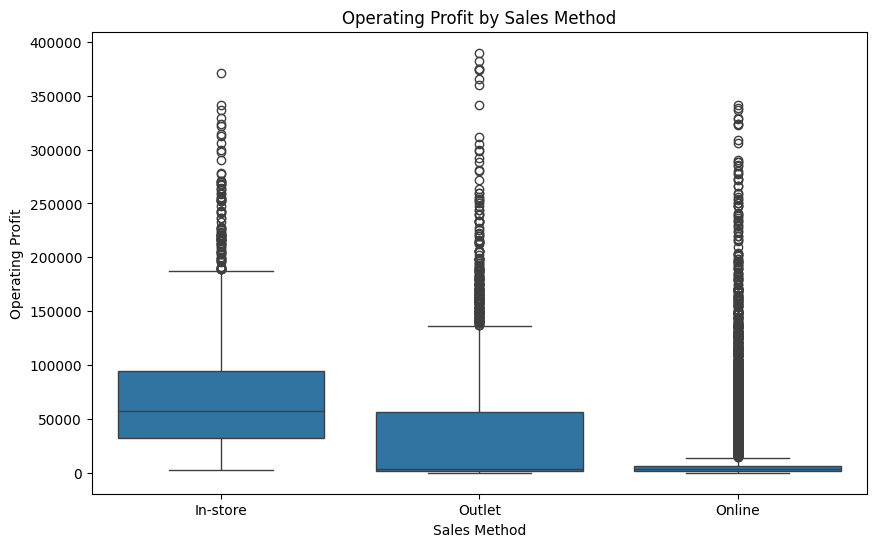

In [17]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Sample data preparation (replace this with your actual DataFrame)
# df = pd.DataFrame({
#     'Sales Method': ['In-store', 'Online', 'Outlet', 'In-store', 'Online', 'Outlet'],
#     'Operating Profit': ['$100', '$200', '$150', '$120', '$210', '$160']
# })

# Ensure all values in 'Operating Profit' are strings
df['Operating Profit'] = df['Operating Profit'].astype(str)

# Remove dollar signs and commas, then convert to numeric
df['Operating Profit'] = df['Operating Profit'].str.replace('$', '').str.replace(',', '').astype(float)

# Now you can fill missing values with the mean
df['Operating Profit'] = df['Operating Profit'].fillna(df['Operating Profit'].mean())

# Group data by 'Sales Method'
groups = [group['Operating Profit'].values for name, group in df.groupby('Sales Method')]

# Conduct ANOVA test
f_statistic, p_value = stats.f_oneway(*groups)

print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference between the groups.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the groups.")

# Visualization using box plots
plt.figure(figsize=(10, 6))
sns.boxplot(x='Sales Method', y='Operating Profit', data=df)
plt.title('Operating Profit by Sales Method')
plt.xlabel('Sales Method')
plt.ylabel('Operating Profit')
plt.show()

4. Interpret Results:
If the p-value is less than your chosen significance level (e.g., 0.05), you reject the null hypothesis and conclude that there is a significant difference in profit between sales methods.
If the p-value is greater than your significance level, you fail to reject the null hypothesis and conclude that there is no significant evidence of a difference in profit between sales methods.

The F-statistic is a value calculated in an Analysis of Variance (ANOVA) test. It represents the ratio of the variance between groups to the variance within groups.
In simpler terms:
A larger F-statistic indicates that the differences between group means are more significant compared to the variation within each group. This suggests that the factor you are testing (e.g., sales method) has a stronger effect on the outcome (e.g., profit).
A smaller F-statistic suggests that the differences between group means are less pronounced compared to the variation within each group. This indicates that the factor you are testing may not have a strong effect on the outcome.
Interpretation:
The F-statistic alone doesn't tell you whether to reject or accept the null hypothesis. You need to compare it to a critical value from the F-distribution or look at the associated p-value to make a decision.

1. Sales Forecasting:
Problem: Predict future sales for different products, regions, or sales methods.
Possible Models: Time series forecasting models (ARIMA, Prophet), regression models (Linear Regression, Random Forest).
Business Value: Optimize inventory management, production planning, and pricing strategies.

Sales Forecasting: Problem: Predict future sales for sales methods. for Adidas dataset

In [18]:
pip install pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


<>:17: SyntaxWarning:

invalid escape sequence '\$'

<>:17: SyntaxWarning:

invalid escape sequence '\$'

/var/folders/_s/qv4_227j5qdbtdr3gprpz2bh0000gn/T/ipykernel_22342/1697036103.py:17: SyntaxWarning:

invalid escape sequence '\$'



  Using cached matplotlib-3.9.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.2.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.53.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (162 kB)
  Using cached kiwisolver-1.4.5-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.4 kB)
  Using cached pillow-10.4.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (9.2 kB)
  Using cached pyparsing-3.1.2-py3-none-any.whl.metadata (5.1 kB)
Using cached matplotlib-3.9.2-cp312-cp312-macosx_11_0_arm64.whl (7.8 MB)
Using cached contourpy-1.2.1-cp312-cp312-macosx_11_0_arm64.whl (245 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.53.1-cp312-cp312-macosx_11_0_arm64.whl (2.2 MB)
Using cached kiwisolver-1.4.5-cp312-cp312-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-10.4.0-cp312-cp312-macosx_11_0_arm64.whl (3.4 MB)
Using cached pyparsing-3.1.2-py3-none-any.

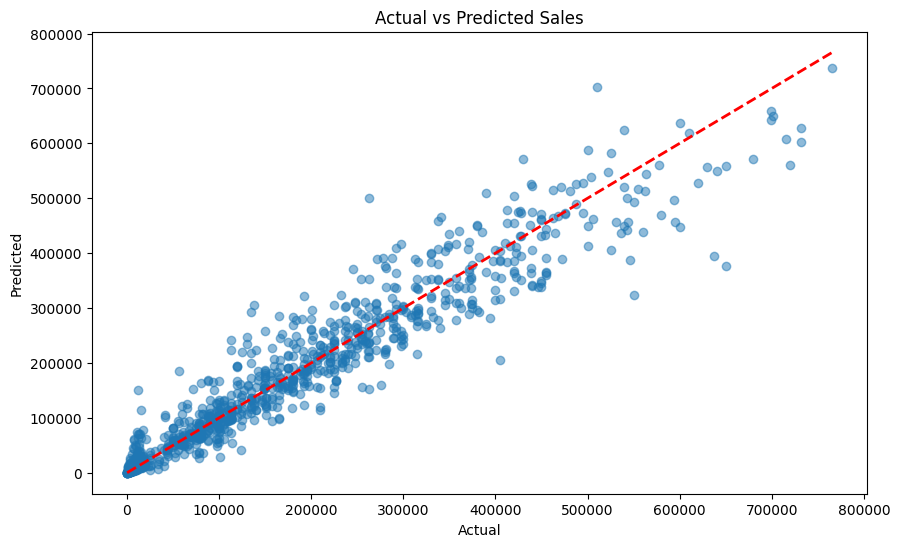

Predicted Total Sales: 46742.67


In [11]:
import pandas as pd
import numpy as np
%pip install matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load your DataFrame (example with a CSV file)
df = pd.read_csv('data/Adidas US Sales Datasets.csv')

# Convert 'Invoice Date' to datetime
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'], format="%d/%m/%Y", dayfirst=True)

# Clean 'Total Sales' column
df['Total Sales'] = df['Total Sales'].str.replace('[\$,]', '', regex=True).astype(float)

# Clean 'Units Sold' column
df['Units Sold'] = df['Units Sold'].str.replace(',', '').astype(float)

# Encode categorical variables
df['Product'] = df['Product'].astype('category').cat.codes
df['Region'] = df['Region'].astype('category').cat.codes

# Extract date-related features
df['Year'] = df['Invoice Date'].dt.year
df['Month'] = df['Invoice Date'].dt.month
df['Day'] = df['Invoice Date'].dt.day
df['DayOfWeek'] = df['Invoice Date'].dt.dayofweek
df['WeekOfYear'] = df['Invoice Date'].dt.isocalendar().week

# Define features and target variable
X = df[['Product', 'Region', 'Units Sold', 'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear']]
y = df['Total Sales']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")

# Plot actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Sales')
plt.show()

# Example prediction
example_data = pd.DataFrame({
    'Product': [0],  # Replace with actual encoded product value
    'Region': [0],   # Replace with actual encoded region value
    'Units Sold': [100],  # Example units sold
    'Year': [2023],
    'Month': [10],
    'Day': [1],
    'DayOfWeek': [0],
    'WeekOfYear': [40]
})
example_prediction = model.predict(example_data)
print(f"Predicted Total Sales: {example_prediction[0]}")

In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Load your DataFrame (example with a CSV file)
df = pd.read_csv('data/Adidas US Sales Datasets.csv')

# Convert 'Invoice Date' to datetime
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'], format="%d/%m/%Y", dayfirst=True)

# Clean 'Total Sales' column
df['Total Sales'] = df['Total Sales'].str.replace('[\$,]', '', regex=True).astype(float)

# Clean 'Units Sold' column
df['Units Sold'] = df['Units Sold'].str.replace(',', '').astype(float)

# Encode categorical variables
df['Product'] = df['Product'].astype('category').cat.codes
df['Region'] = df['Region'].astype('category').cat.codes

# Extract date-related features
df['Year'] = df['Invoice Date'].dt.year
df['Month'] = df['Invoice Date'].dt.month
df['Day'] = df['Invoice Date'].dt.day
df['DayOfWeek'] = df['Invoice Date'].dt.dayofweek
df['WeekOfYear'] = df['Invoice Date'].dt.isocalendar().week

# Define features and target variable
X = df[['Product', 'Region', 'Units Sold', 'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear']]
y = df['Total Sales']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Save the model
joblib.dump(model, 'sales_model.pkl')

<>:15: SyntaxWarning:

invalid escape sequence '\$'

<>:15: SyntaxWarning:

invalid escape sequence '\$'

/var/folders/_s/qv4_227j5qdbtdr3gprpz2bh0000gn/T/ipykernel_22342/1043311190.py:15: SyntaxWarning:

invalid escape sequence '\$'



['sales_model.pkl']

In [2]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output, State
import pandas as pd
import joblib
import numpy as np

# Load the trained model
model = joblib.load('sales_model.pkl')

# Initialize the Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Adidas Sales Prediction"),
    html.Div([
        html.Label("Product"),
        dcc.Input(id='product', type='number', value=0),
    ]),
    html.Div([
        html.Label("Region"),
        dcc.Input(id='region', type='number', value=0),
    ]),
    html.Div([
        html.Label("Units Sold"),
        dcc.Input(id='units_sold', type='number', value=100),
    ]),
    html.Div([
        html.Label("Year"),
        dcc.Input(id='year', type='number', value=2023),
    ]),
    html.Div([
        html.Label("Month"),
        dcc.Input(id='month', type='number', value=10),
    ]),
    html.Div([
        html.Label("Day"),
        dcc.Input(id='day', type='number', value=1),
    ]),
    html.Div([
        html.Label("Day of Week"),
        dcc.Input(id='day_of_week', type='number', value=0),
    ]),
    html.Div([
        html.Label("Week of Year"),
        dcc.Input(id='week_of_year', type='number', value=40),
    ]),
    html.Button('Predict', id='predict-button', n_clicks=0),
    html.Div(id='prediction-output')
])

@app.callback(
    Output('prediction-output', 'children'),
    Input('predict-button', 'n_clicks'),
    State('product', 'value'),
    State('region', 'value'),
    State('units_sold', 'value'),
    State('year', 'value'),
    State('month', 'value'),
    State('day', 'value'),
    State('day_of_week', 'value'),
    State('week_of_year', 'value')
)
def predict_sales(n_clicks, product, region, units_sold, year, month, day, day_of_week, week_of_year):
    if n_clicks > 0:
        input_data = np.array([[product, region, units_sold, year, month, day, day_of_week, week_of_year]])
        prediction = model.predict(input_data)
        return f'Predicted Total Sales: ${prediction[0]:,.2f}'
    return ''

if __name__ == '__main__':
    app.run_server(debug=True)

In [1]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [4]:
web: python app.py

SyntaxError: invalid syntax (1575695500.py, line 1)